# 3D simple perturbation: K-Order Liénard–Wiechert correction

The zeroth-order trajectory is the exact motion of a single charge in the
constant longitudinal external field `E_Z`.  The first-order perturbation
in position and momentum is then obtained by integrating the
Liénard–Wiechert fields produced by all *other* macroparticles along that
zeroth-order trajectory.

## Unit conventions

A hybrid unit system is used for the dynamical variables:

- length          : m
- time            : s
- mass            : MeV / c²
- momentum        : MeV / c
- charge          : units of the elementary-charge magnitude `|e|`
- electric field  : MV / m

`calc_LW_fields` temporarily switches to pure SI (coulombs, volts per
metre, tesla) to evaluate the electromagnetic field formulas; the
returned force is converted back to the hybrid system before being fed
into the state-vector derivative.  Momenta are converted to the
dimensionless `β·γ` only for plotting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import qmc
from scipy.integrate import solve_ivp

from joblib import Parallel, delayed

plt.rcParams["font.family"] = "serif"

In [2]:
# ---------------------------------------------------------------------
# Physical constants
# ---------------------------------------------------------------------
C_SI         = 299_792_458          # speed of light                    [m/s]
EPSILON_0_SI = 8.8541878128e-12     # vacuum permittivity               [A·s/(V·m)]
E_CHARGE_SI  = 1.602176634e-19      # elementary charge magnitude |e|   [C]
M_E_SI       = 9.1093837015e-31     # electron rest mass                [kg]
M_E          = 0.511                # electron rest mass                [MeV/c²]
Q_E          = -1.0                 # electron charge                   [|e|]

In [3]:
# ---------------------------------------------------------------------
# Simulation parameters
# ---------------------------------------------------------------------
E_Z              = -1.0              # longitudinal external E-field     [MV/m]
TOTAL_CHARGE_SI  = -1e-12            # total bunch charge                [C]
N_PARTICLES      = 2**8              # number of macroparticles          [1]
T_END            = 3e-9              # end of integration                [s]

USE_CIC_SOFTENING = True             # whether to use softening in the CIC force calculation
R_SOFT = 0.00005                     # softening radius for CIC (if enabled)  [m]

# ---------------------------------------------------------------------
# TPSA perturbation parameters
# ---------------------------------------------------------------------
PERTURB_ORDER = 4                   # maximum perturbation order K       [1]
NUM_STEPS     = 800                 # number of fixed time steps         [1]

# ---------------------------------------------------------------------
# TPSA perturbation parameters
# ---------------------------------------------------------------------

N_LOWER_ORDERS_TO_PLOT = PERTURB_ORDER-1 # Set to 0 to plot only the K-th order curve (in which case reference-data difference is shown)

# ---------------------------------------------------------------------
# Time-stepping loop (parallel kernels per step).
#   INTEGRATOR = "euler" -> explicit Euler, 1 derivative eval per step,    O(dt)
#   INTEGRATOR = "heun"  -> RK2 predictor-corrector, 2 evals per step,     O(dt^2)
# ---------------------------------------------------------------------
INTEGRATOR = "euler"

# ---------------------------------------------------------------------
# Derived quantities
# ---------------------------------------------------------------------
N_REAL_PARTICLES = np.abs(TOTAL_CHARGE_SI) / E_CHARGE_SI    # real electrons in the bunch
MACRO_WEIGHT     = N_REAL_PARTICLES / N_PARTICLES           # real particles per macroparticle

# Signed macroparticle charge / mass for the pure-SI L-W field calculation.
Q_MACRO_SI = Q_E * MACRO_WEIGHT * E_CHARGE_SI               # [C]
M_MACRO_SI = MACRO_WEIGHT * M_E_SI                          # [kg]

In [4]:
def p_to_betagamma(p):
    """Convert momentum from [MeV/c] to the dimensionless ``β·γ``.

    Parameters
    ----------
    p : array_like
        Momentum in MeV/c.

    Returns
    -------
    array_like
        Same shape as ``p``, dimensionless.
    """
    return p / M_E


def sample_ellipsoid_qmc(mean, radii, n_particles):
    """Quasi-Monte-Carlo sampling of a 3D ellipsoid using a Sobol sequence.

    Produces a low-discrepancy, clump-free, uniform-density set of points
    inside the ellipsoid centred at ``mean`` with semi-axes ``radii``.

    Parameters
    ----------
    mean : array_like, shape (3,)
        Centre of the ellipsoid [m].
    radii : array_like, shape (3,)
        Semi-axis lengths [m].
    n_particles : int
        Number of samples (best results when this is a power of two).

    Returns
    -------
    points : ndarray, shape (n_particles, 3)
        Sampled positions [m].
    """
    sampler = qmc.Sobol(d=3, scramble=False)
    u = sampler.random(n=n_particles)
    u1, u2, u3 = u[:, 0], u[:, 1], u[:, 2]

    # Uniform density inside the unit ball: r ~ u1^(1/3) absorbs the radial
    # Jacobian; cos(θ) uniform in [-1, 1] gives a uniform direction.
    r         = u1 ** (1.0 / 3.0)
    cos_theta = 1.0 - 2.0 * u2
    sin_theta = np.sqrt(1.0 - cos_theta ** 2)
    phi       = 2.0 * np.pi * u3

    x_sphere = r * sin_theta * np.cos(phi)
    y_sphere = r * sin_theta * np.sin(phi)
    z_sphere = r * cos_theta

    points = np.empty((n_particles, 3))
    points[:, 0] = mean[0] + radii[0] * x_sphere
    points[:, 1] = mean[1] + radii[1] * y_sphere
    points[:, 2] = mean[2] + radii[2] * z_sphere
    return points

In [5]:
# Reference-simulation data.
#   column  0     time           [s]
#   columns 1..3  mean position  (x, y, z)   [m]
#   columns 4..6  position sigma (x, y, z)   [m]
#   columns 7..9  mean momentum  (x, y, z)   [MeV/c]
data_3d_simple = np.loadtxt("./data/3d_data_simple.csv", delimiter=",")

data_times = data_3d_simple[:, 0]
data_position_means_si  = data_3d_simple[:, 1:4]    # [m]
data_position_sigmas_si = data_3d_simple[:, 4:7]    # [m]
data_momentum_means_pp  = data_3d_simple[:, 7:10]   # [MeV/c]
data_momentum_sigmas_pp = data_3d_simple[:, 10:]    # [MeV/c]

def plot_data(ax, x_analytic, y_analytic, x_data, y_data, plot_diff=True):
    y_data_interp = np.interp(x_analytic, x_data, y_data)

    ax.plot(x_analytic, y_data_interp, label="Simulation Data", color="black", linestyle="--", linewidth=0.5)
    ax.legend(loc="upper left")

    if not plot_diff:
        return

    ax_diff = ax.twinx()
    y_diff = np.abs(y_data_interp - y_analytic)
    ax_diff.plot(x_analytic, y_diff, label="Difference \nSimulation - Analytic", color="red", linewidth=0.5)
    ax_diff.set_ylabel(ax.get_ylabel(), color="red")
    ax_diff.tick_params(axis='y', labelcolor="red")
    ax_diff.legend(loc="upper right")

# K-order Liénard–Wiechert perturbation via TPSA

The perturbation hierarchy is unrolled to arbitrary order $K$ using a
lightweight **Truncated Power Series Algebra** (TPSA) layer compiled with
`numba.njit`:

* every scalar / 3-vector dynamical quantity is stored as a length-$K{+}1$
  array of $\varepsilon$-coefficients
  $f(\varepsilon)=f^{(0)}+\varepsilon f^{(1)}+\dots+\varepsilon^{K}f^{(K)}$;
* the self-field is tagged with one extra factor of $\varepsilon$, so the
  $\varepsilon^k$ coefficient of the equations of motion reproduces the
  classical $k$-th order perturbation (matching `equations.txt`);
* the per-step kernel is parallelised over the target trajectories via
  `numba.prange`;
* the per-pair retarded time is itself a TPSA scalar: a robust scalar
  Newton solve fixes the $\varepsilon^0$ part, after which a few
  TPSA-Newton refinement iterations bring all higher orders in.

The 0-th-order trajectory is overwritten by its closed-form
external-field solution at the end of every step, so only the genuine
perturbative orders $k\!\ge\!1$ accumulate Euler error.  RK-style
stepping is straightforward in the same TPSA ring but adds intra-step
source-history bookkeeping; we stick with explicit Euler for clarity.

In [6]:
import numpy as np
from numba import njit, prange

# TPSA convention
#   scalar  : shape (K+1,)        -- coefficients of 1, eps, eps^2, ..., eps^K
#   3-vector: shape (K+1, 3)      -- one TPSA scalar per Cartesian component
# Every operation writes into a caller-supplied ``out`` buffer to keep the
# kernel allocation-free.

@njit(cache=True, fastmath=True)
def tp_mul(a, b, out):                       # out = a * b   (Cauchy product)
    K1 = a.shape[0]
    for n in range(K1):
        s = 0.0
        for m in range(n + 1):
            s += a[m] * b[n - m]
        out[n] = s

@njit(cache=True, fastmath=True)
def tp_inv(a, out):                          # out = 1 / a   (a[0] != 0)
    K1 = a.shape[0]
    out[0] = 1.0 / a[0]
    for n in range(1, K1):
        s = 0.0
        for m in range(1, n + 1):
            s += a[m] * out[n - m]
        out[n] = -out[0] * s

@njit(cache=True, fastmath=True)
def tp_sqrt(a, out):                         # out = sqrt(a) (a[0] > 0)
    K1 = a.shape[0]
    out[0] = np.sqrt(a[0])
    inv2 = 0.5 / out[0]
    for n in range(1, K1):
        s = 0.0
        for m in range(1, n):
            s += out[m] * out[n - m]
        out[n] = (a[n] - s) * inv2

@njit(cache=True, fastmath=True)
def tp_dot3(u, v, out):                      # out = u . v   (scalar)
    K1 = u.shape[0]
    for n in range(K1):
        s = 0.0
        for m in range(n + 1):
            nm = n - m
            s += (u[m, 0] * v[nm, 0]
                + u[m, 1] * v[nm, 1]
                + u[m, 2] * v[nm, 2])
        out[n] = s

@njit(cache=True, fastmath=True)
def tp_cross3(u, v, out):                    # out = u x v   (3-vector)
    K1 = u.shape[0]
    for n in range(K1):
        sx = 0.0; sy = 0.0; sz = 0.0
        for m in range(n + 1):
            nm = n - m
            sx += u[m, 1] * v[nm, 2] - u[m, 2] * v[nm, 1]
            sy += u[m, 2] * v[nm, 0] - u[m, 0] * v[nm, 2]
            sz += u[m, 0] * v[nm, 1] - u[m, 1] * v[nm, 0]
        out[n, 0] = sx; out[n, 1] = sy; out[n, 2] = sz

@njit(cache=True, fastmath=True)
def tp_scalvec(a, u, out):                   # out = (scalar a) * (vector u)
    K1 = a.shape[0]
    for n in range(K1):
        sx = 0.0; sy = 0.0; sz = 0.0
        for m in range(n + 1):
            nm = n - m
            sx += a[m] * u[nm, 0]
            sy += a[m] * u[nm, 1]
            sz += a[m] * u[nm, 2]
        out[n, 0] = sx; out[n, 1] = sy; out[n, 2] = sz

TPSA simulation: K=6, N=256, steps=300, integrator=heun, wall time 10.73 s


c:\Users\Axel-\miniconda3\envs\semester-project\Lib\site-packages\numpy\_core\_methods.py:190: RuntimeWarning: overflow encountered in square
  x = um.square(x, out=x)


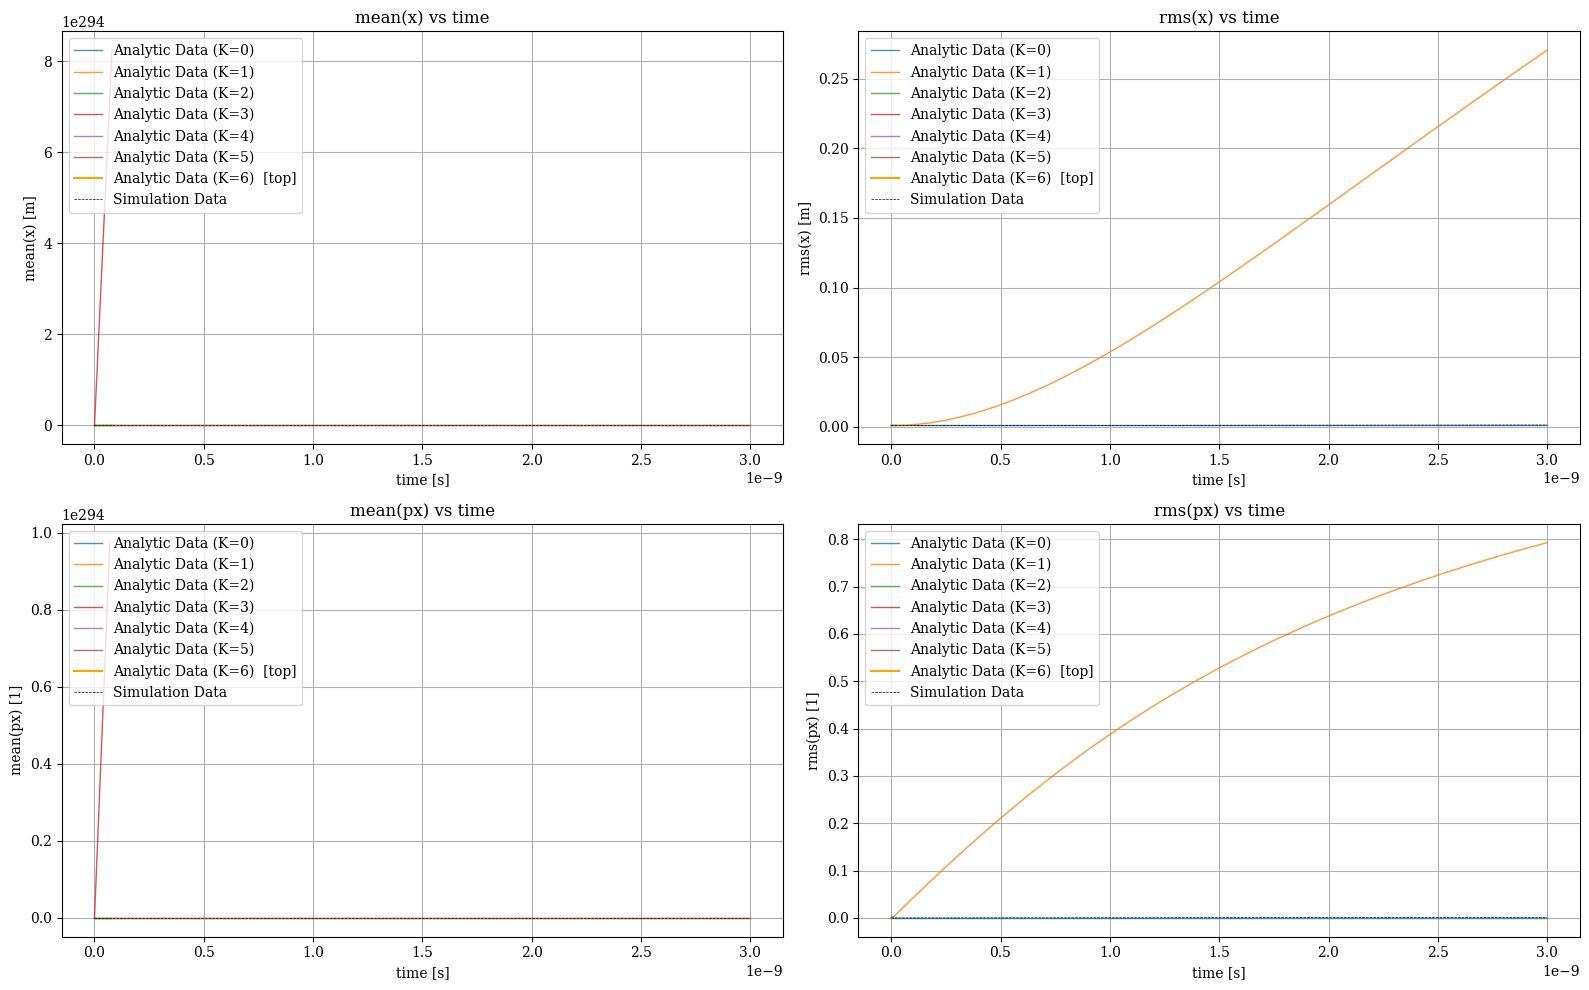

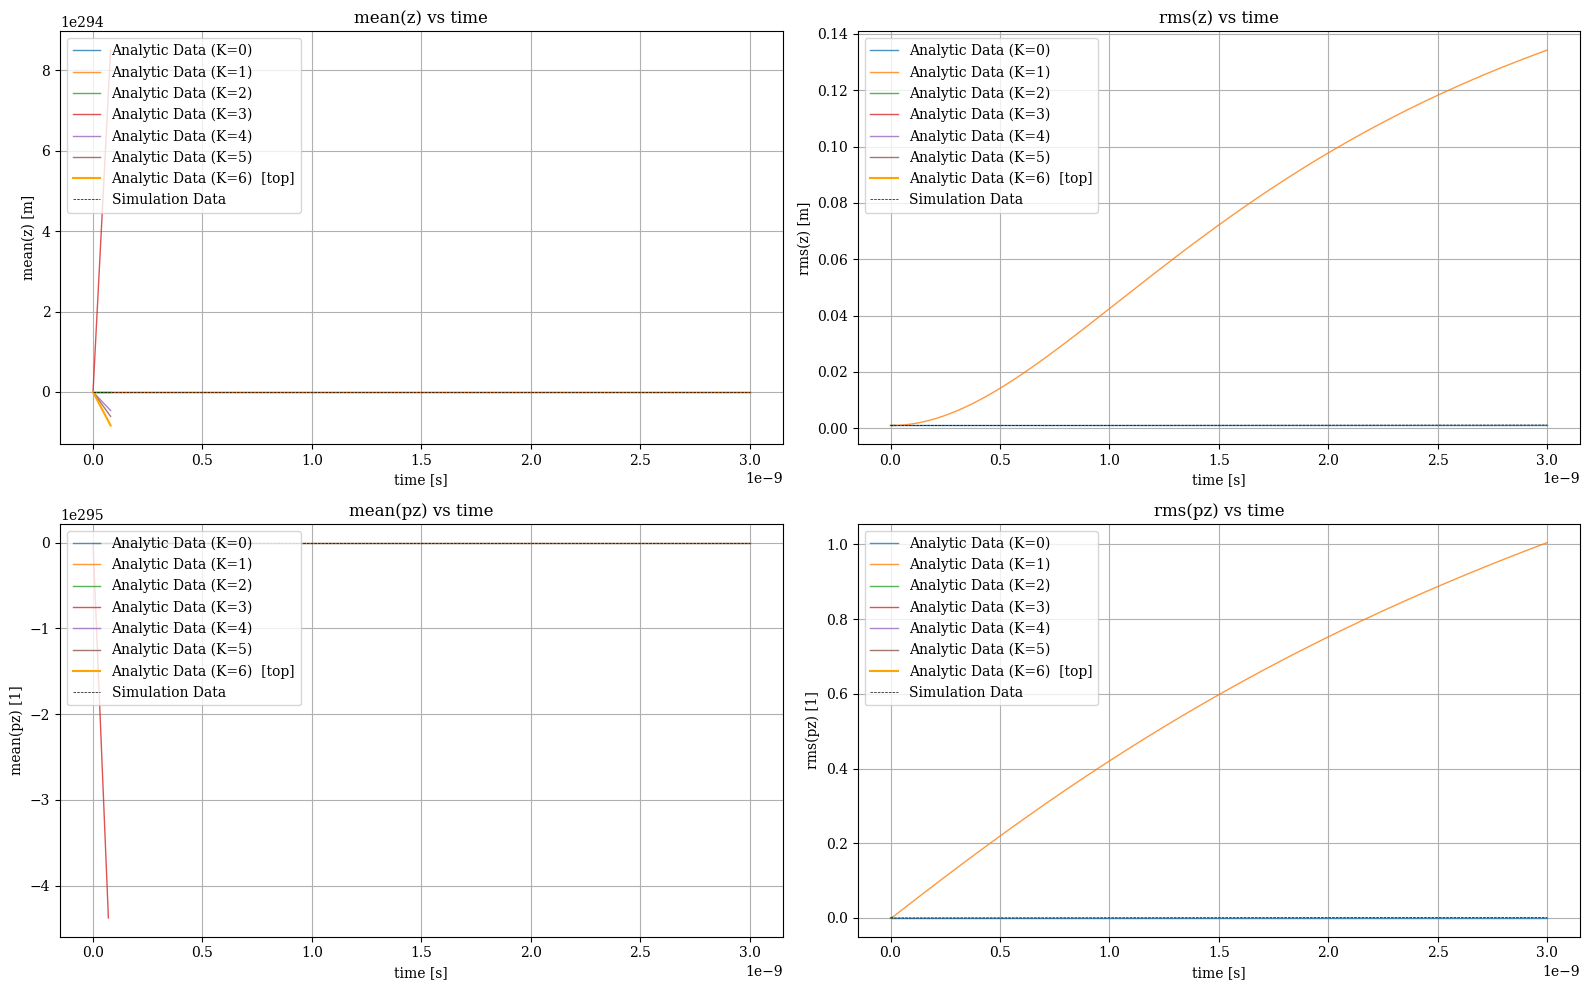

In [7]:
from tpsa_kernel_helpers import (
    _eval_derivs,
    _apply_update,
    _apply_heun,
    _solve_tr_scalar,
    step_euler,
    step_heun,
)

_ = (_eval_derivs, _apply_update, _apply_heun, _solve_tr_scalar, step_euler, step_heun)


In [8]:
# ---------------------------------------------------------------------
# Initial conditions: identical sampling scheme to the reference notebook.
# ---------------------------------------------------------------------
r0_particles = sample_ellipsoid_qmc(
    mean        = data_position_means_si[0],
    radii       = np.sqrt(5.0) * data_position_sigmas_si[0],
    n_particles = N_PARTICLES,
)
p0_particles = sample_ellipsoid_qmc(
    mean        = data_momentum_means_pp[0],
    radii       = np.sqrt(5.0) * data_momentum_sigmas_pp[0],
    n_particles = N_PARTICLES,
)

# ---------------------------------------------------------------------
# Allocate the TPSA history (NUM_STEPS, N, K+1, 3).  All higher orders
# start at zero; the 0-th order is seeded with the initial conditions.
# ---------------------------------------------------------------------
K     = PERTURB_ORDER
times = np.linspace(0.0, T_END, NUM_STEPS)
dt    = times[1] - times[0]

hist_r = np.zeros((NUM_STEPS, N_PARTICLES, K + 1, 3))
hist_p = np.zeros((NUM_STEPS, N_PARTICLES, K + 1, 3))
hist_r[0, :, 0, :] = r0_particles
hist_p[0, :, 0, :] = p0_particles


dr1 = np.empty((N_PARTICLES, K + 1, 3))
dp1 = np.empty((N_PARTICLES, K + 1, 3))
dr2 = np.empty_like(dr1) if INTEGRATOR == "heun" else None
dp2 = np.empty_like(dp1) if INTEGRATOR == "heun" else None

import time as _tm
_t0 = _tm.time()
for t_idx in range(1, NUM_STEPS):
    if INTEGRATOR == "euler":
        step_euler(t_idx, dt, hist_r, hist_p, times, r0_particles, p0_particles,
                   dr1, dp1)
    elif INTEGRATOR == "heun":
        step_heun (t_idx, dt, hist_r, hist_p, times, r0_particles, p0_particles,
                   dr1, dp1, dr2, dp2)
    else:
        raise ValueError(f"unknown INTEGRATOR {INTEGRATOR!r}")
    print(f"Completed step {t_idx}/{NUM_STEPS - 1} (t = {times[t_idx]:.3e} s)", end="\r")
print(f"TPSA simulation: K={K}, N={N_PARTICLES}, steps={NUM_STEPS}, "
      f"integrator={INTEGRATOR}, wall time {_tm.time() - _t0:.2f} s")



#----------------------------------------------------------------------
# Convergence analysis (max relative change of dp/dt per order, per time step of any trajectory).
#----------------------------------------------------------------------

# hist_r / hist_p   (T, N, K+1, 3)  [m] / [MeV/c]
convergence_ratios = np.zeros((hist_p.shape[0], K))   
for k in range(1, K + 1):
    for t in range(hist_p.shape[0]): 
        
        max_ratio_k = 0.0
        for i in range(N_PARTICLES):
            dp_dt_k, dp_dt_k_minus_1 = hist_p[t, i, k, :], hist_p[t, i, k-1, :]
            norm_k = np.linalg.norm(dp_dt_k)
            norm_k_minus_1 = np.linalg.norm(dp_dt_k_minus_1)

            ratio_k_i = 0 
            if norm_k_minus_1 > 1e-15:
                ratio_k_i = norm_k / norm_k_minus_1
            if ratio_k_i > max_ratio_k:
                max_ratio_k = ratio_k_i

        convergence_ratios[t, k-1] = max_ratio_k
    
            
        
if norm_k_minus_1 > 1e-15:
        R_k = norm_k / norm_k_minus_1

# ---------------------------------------------------------------------
# Cumulative trajectories per perturbation order.
# cum[..., k, :] = r^(0) + r^(1) + ... + r^(k); the K-th slice is the
# full perturbative reconstruction (kept for the per-particle arrays).
# ---------------------------------------------------------------------
cum_r           = np.cumsum(hist_r, axis=2)
cum_p           = np.cumsum(hist_p, axis=2)
r_t_particles   = cum_r[:, :, K, :].transpose(1, 0, 2)   # (N, T, 3)  [m]
p_t_particles   = cum_p[:, :, K, :].transpose(1, 0, 2)   # (N, T, 3)  [MeV/c]

# Bunch statistics per cumulative order (axes: time, order, component).
mean_r_orders   = cum_r.mean(axis=1)                     # (T, K+1, 3)  [m]
rms_r_orders    = cum_r.std (axis=1)
mean_p_orders   = cum_p.mean(axis=1)                     # (T, K+1, 3)  [MeV/c]
rms_p_orders    = cum_p.std (axis=1)

TPSA simulation: K=4, N=256, steps=800, integrator=euler, wall time 14.02 s


In [9]:
hist_p[:, 0:2, 4, 2]

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]], shape=(800, 2))

# PLotting

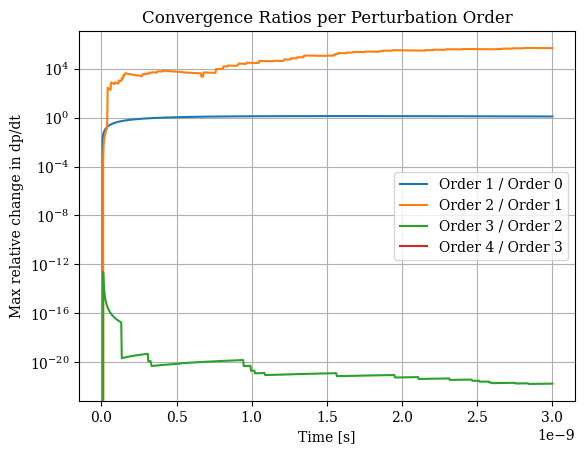

In [10]:
for k in range(K):
    plt.plot(times, convergence_ratios[:, k], label=f"Order {k+1} / Order {k}")
plt.yscale("log")
plt.xlabel("Time [s]")
plt.ylabel("Max relative change in dp/dt")
plt.title("Convergence Ratios per Perturbation Order")
plt.legend()
plt.grid()

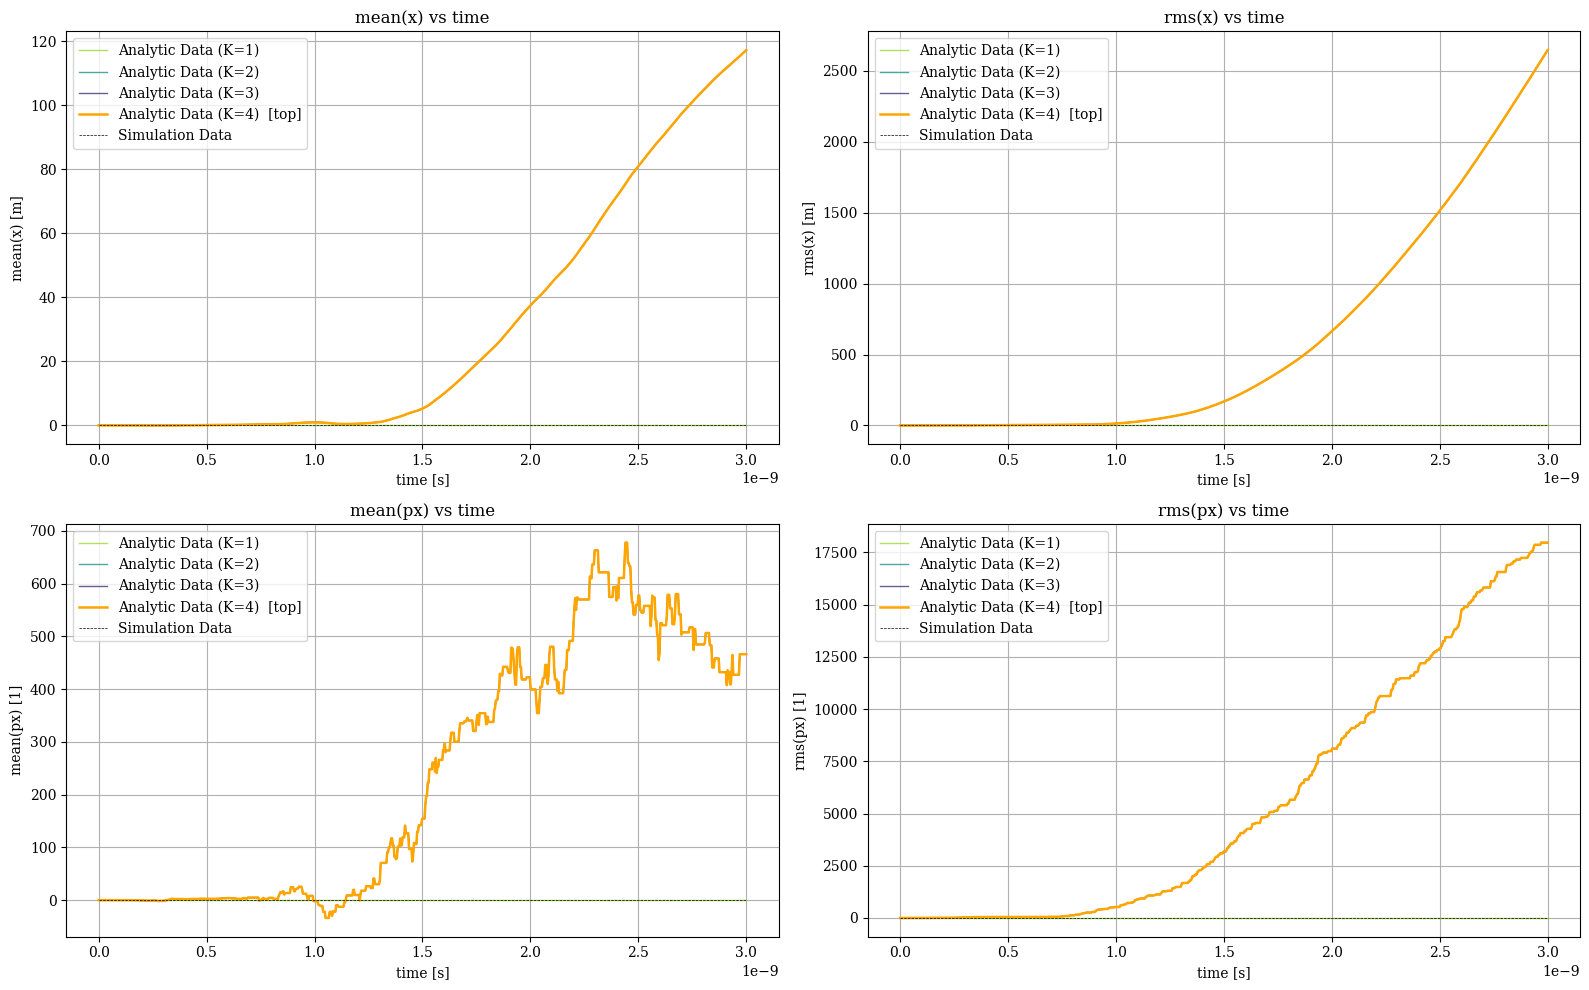

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

orders     = list(range(max(0, K - N_LOWER_ORDERS_TO_PLOT), K + 1))
plot_diff  = (len(orders) == 1)
_palette   = plt.cm.viridis(np.linspace(0.85, 0.15, max(len(orders) - 1, 1)))
_col_map   = {k: ('orange' if k == K else _palette[i])
              for i, k in enumerate(orders[:-1] + [K])}
_alpha     = lambda k: 1.0 if k == K else 0.8
_lw        = lambda k: 1.8 if k == K else 1.0
_col       = lambda k: _col_map[k]

for k in orders:
    lbl = f"Analytic Data (K={k})" + ("  [top]" if k == K else "")

    axes[0,0].plot(times, mean_r_orders[:, k, 0],                 color = _col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)
    axes[0,1].plot(times, rms_r_orders [:, k, 0],                 color = _col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)
    axes[1,0].plot(times, p_to_betagamma(mean_p_orders[:, k, 0]), color = _col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)
    axes[1,1].plot(times, p_to_betagamma(rms_p_orders [:, k, 0]), color = _col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)

for ax, ylabel, title in zip(
    axes.flat,
    ['mean(x) [m]', 'rms(x) [m]', 'mean(px) [1]', 'rms(px) [1]'],
    ['mean(x) vs time', 'rms(x) vs time', 'mean(px) vs time', 'rms(px) vs time'],
):
    ax.set_xlabel('time [s]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid()
    ax.legend(loc='upper left')

plot_data(axes[0,0], times, mean_r_orders[:, K, 0],                 data_times, data_position_means_si [:, 0],                plot_diff=plot_diff)
plot_data(axes[0,1], times, rms_r_orders [:, K, 0],                 data_times, data_position_sigmas_si[:, 0],                plot_diff=plot_diff)
plot_data(axes[1,0], times, p_to_betagamma(mean_p_orders[:, K, 0]), data_times, p_to_betagamma(data_momentum_means_pp [:, 0]), plot_diff=plot_diff)
plot_data(axes[1,1], times, p_to_betagamma(rms_p_orders [:, K, 0]), data_times, p_to_betagamma(data_momentum_sigmas_pp[:, 0]), plot_diff=plot_diff)

fig.tight_layout()


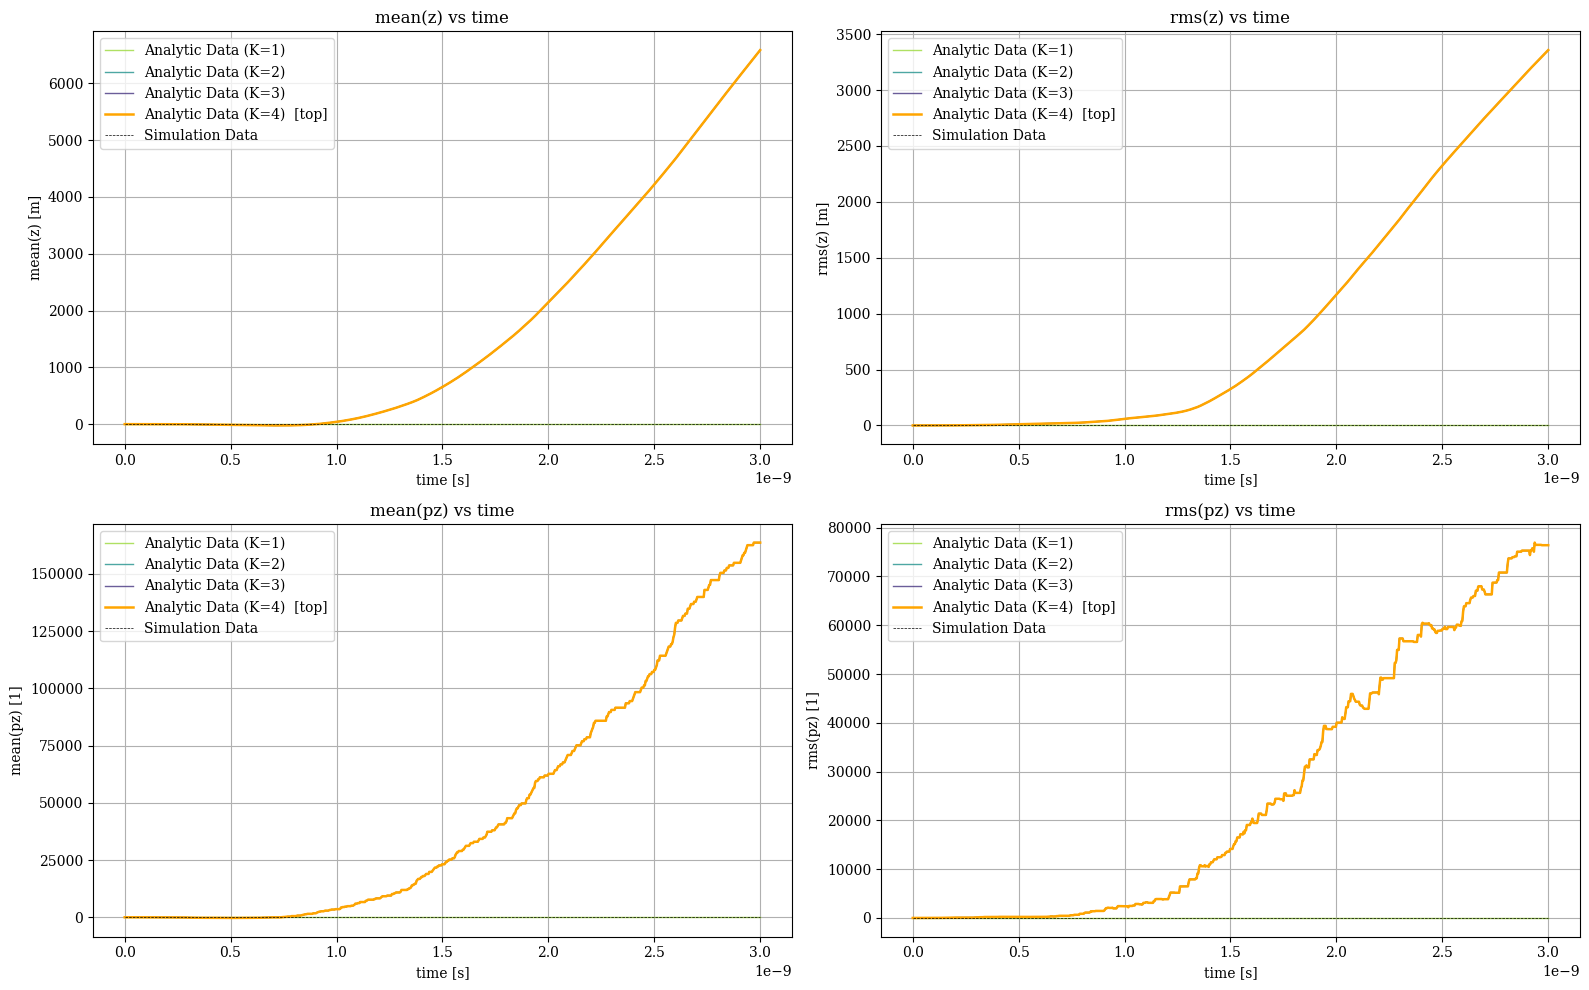

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for k in orders:
    lbl = f"Analytic Data (K={k})" + ("  [top]" if k == K else "")
    axes[0,0].plot(times, mean_r_orders[:, k, 2],                 color=_col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)
    axes[0,1].plot(times, rms_r_orders [:, k, 2],                 color=_col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)
    axes[1,0].plot(times, p_to_betagamma(mean_p_orders[:, k, 2]), color=_col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)
    axes[1,1].plot(times, p_to_betagamma(rms_p_orders [:, k, 2]), color=_col(k), alpha=_alpha(k), linewidth=_lw(k), label=lbl)

for ax, ylabel, title in zip(
    axes.flat,
    ['mean(z) [m]', 'rms(z) [m]', 'mean(pz) [1]', 'rms(pz) [1]'],
    ['mean(z) vs time', 'rms(z) vs time', 'mean(pz) vs time', 'rms(pz) vs time'],
):
    ax.set_xlabel('time [s]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid()
    ax.legend(loc='upper left')

plot_data(axes[0,0], times, mean_r_orders[:, K, 2],                 data_times, data_position_means_si [:, 2],                plot_diff=plot_diff)
plot_data(axes[0,1], times, rms_r_orders [:, K, 2],                 data_times, data_position_sigmas_si[:, 2],                plot_diff=plot_diff)
plot_data(axes[1,0], times, p_to_betagamma(mean_p_orders[:, K, 2]), data_times, p_to_betagamma(data_momentum_means_pp [:, 2]), plot_diff=plot_diff)
plot_data(axes[1,1], times, p_to_betagamma(rms_p_orders [:, K, 2]), data_times, p_to_betagamma(data_momentum_sigmas_pp[:, 2]), plot_diff=plot_diff)

fig.tight_layout()